---
title: "Marine's Lab 1"

format:
  html:
    embed-resources: true

execute:
  echo: true
---


# **PLOT 1**

provided image of plot 1

In [21]:
# import data set
import pandas as pd
from plotnine import *

In [22]:
q1_plot = pd.read_csv("https://raw.githubusercontent.com/mar7neh-ctrl/lab1-gapminder/refs/heads/main/Data/q1data.csv")

In [23]:
q1_plot

,income,life_exp,population,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,1910.0,61.0,29200000.0,2010,Afghanistan,asia,south_asia,asia_west,South Asia
1,11100.0,78.1,2950000.0,2010,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,11100.0,74.7,36000000.0,2010,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,46900.0,81.9,84500.0,2010,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia
4,7680.0,60.8,23400000.0,2010,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa
...,...,...,...,...,...,...,...,...,...
192,20400.0,75.4,28400000.0,2010,Venezuela,americas,america,america_south,Latin America & Caribbean
193,5350.0,73.3,88000000.0,2010,Vietnam,asia,east_asia_pacific,east_asia_pacific,East Asia & Pacific
194,4700.0,67.8,23200000.0,2010,Yemen,asia,middle_east_north_africa,asia_west,Middle East & North Africa
195,3200.0,57.5,13600000.0,2010,Zambia,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


1. what aesthetics are being used, which variables are being mapped to each aesthetic

      point = country

      x = income

      y = life_exp

      color = four_regions

      size = population

2. recreate the plot using plotnine
must have: the geometry, the aesthetics, the scales

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 3 rows containing missing values.


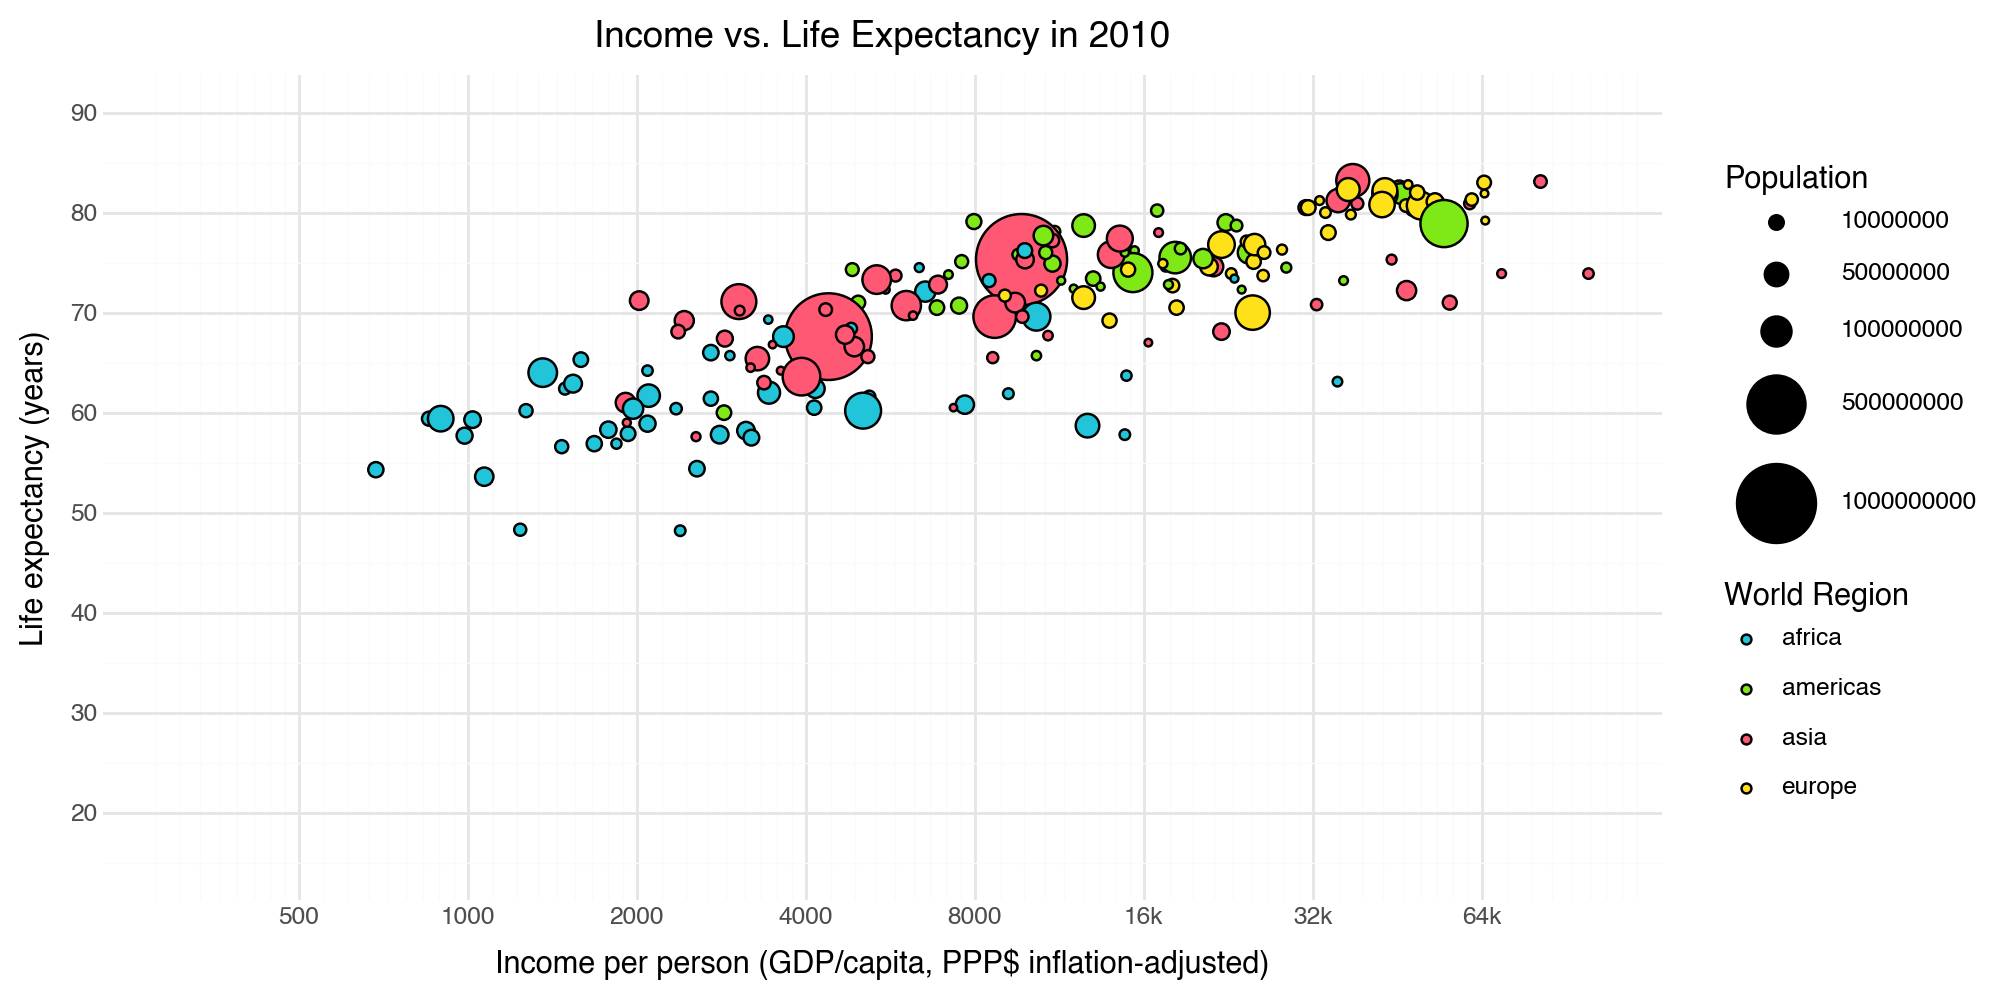

In [24]:
# geom_point for this
# drop "nan" region
q1_plot = q1_plot.dropna(subset=['four_regions'])
(
    ggplot(q1_plot, aes(
        x='income',
        y='life_exp',
        fill='four_regions',
        size='population'
    ))

    + geom_point(
        shape='o',
        color='black',
        stroke=0.5
    )

    + scale_x_log10(
        breaks=[500, 1000, 2000, 4000, 8000, 16000, 32000, 64000],
        labels=['500', '1000', '2000', '4000', '8000', '16k', '32k', '64k'],
        limits=(300, 100000)
    )

    + scale_y_continuous(
        breaks=[20, 30, 40, 50, 60, 70, 80, 90],
        limits=(15, 90)
    )

    + scale_size_continuous(
        breaks=[10000000, 50000000, 100000000, 500000000, 1000000000],
        range=(1, 18)
    )

    + scale_fill_manual(values={
        'africa': '#21C4D8',
        'americas': '#7FE817',
        'asia': '#FF5874',
        'europe': '#FFE11A'
    })

    + labs(
        title="Income vs. Life Expectancy in 2010",
        x='Income per person (GDP/capita, PPP$ inflation-adjusted)',
        y='Life expectancy (years)',
        fill="World Region",
        size="Population"
    )

    + theme_minimal()
    + theme(
        figure_size = (10,5)
    )
)

3. what other geometries could you use here besides geom_point?

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 1 rows containing missing values.


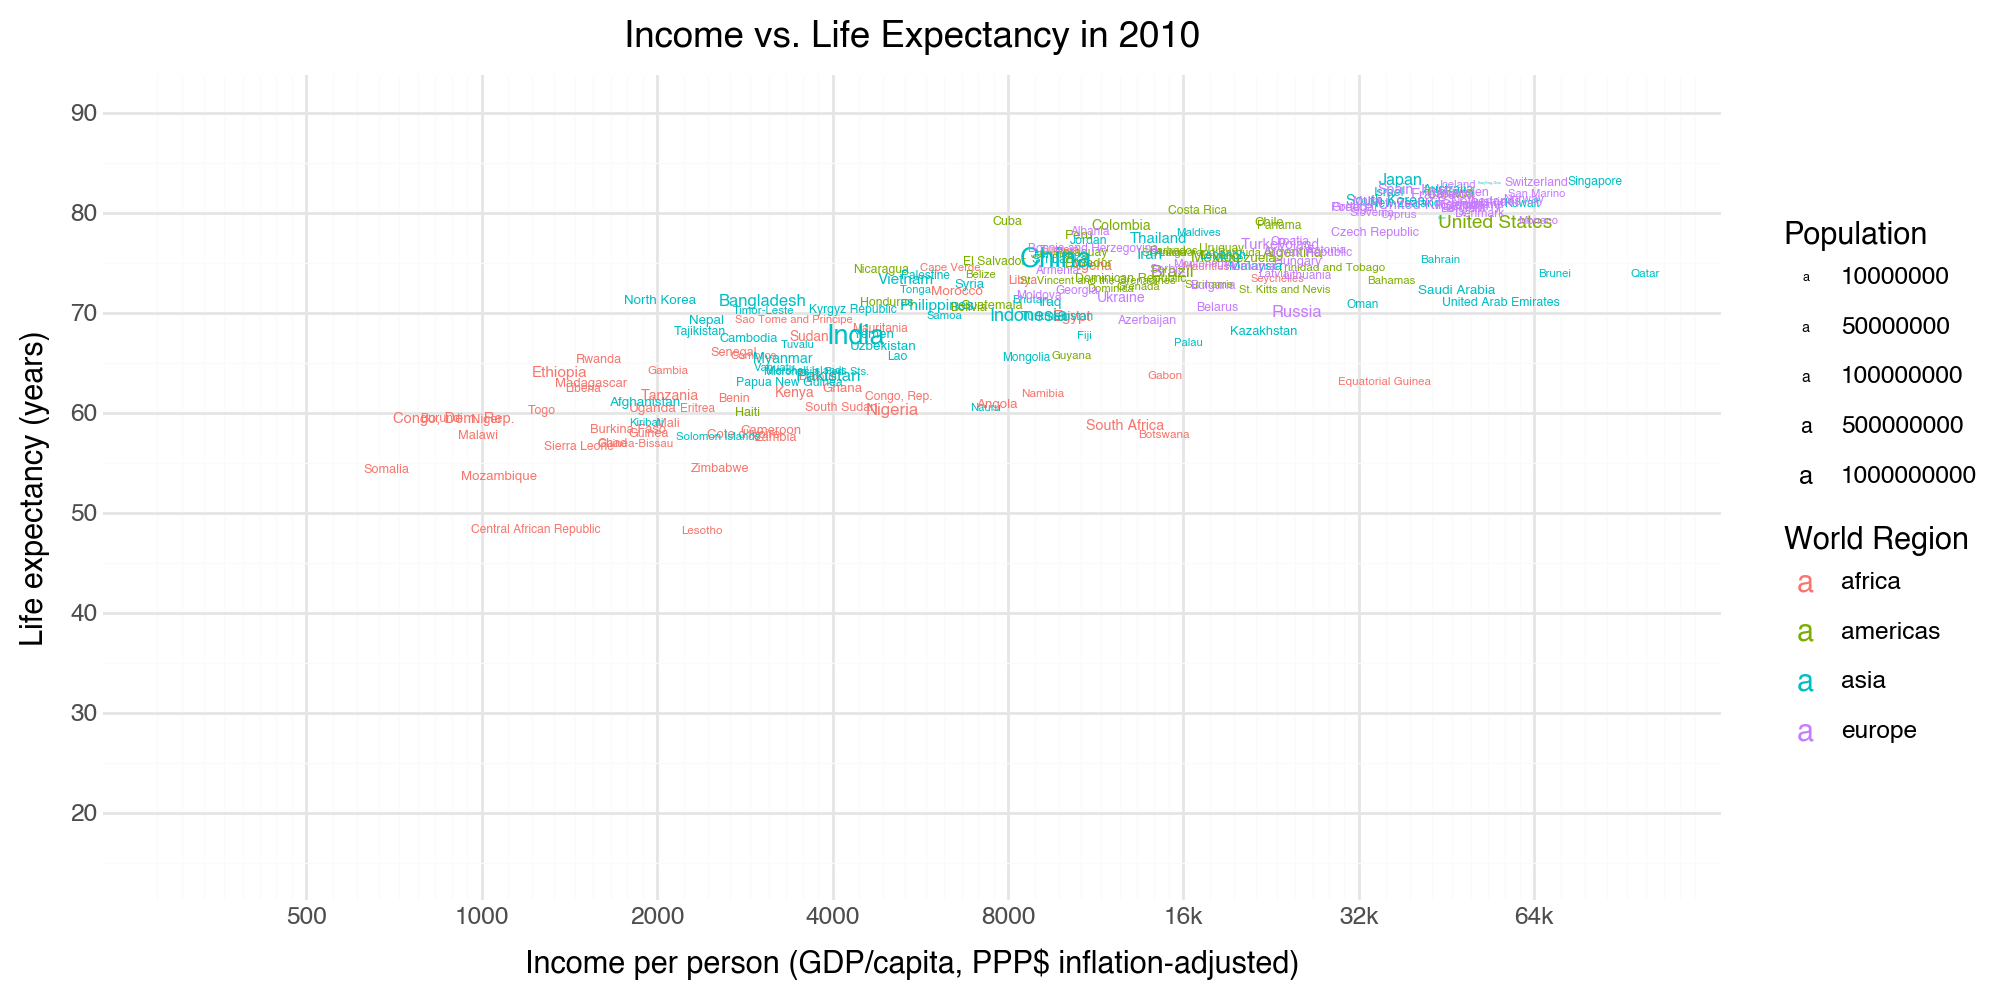

In [25]:
# could technically do jitter but too close
# this is a text plot!
# droping the "nan" region first
q1_plot = q1_plot.dropna(subset=['four_regions'])

(
    ggplot(q1_plot, aes(
        x='income',
        y='life_exp',
        label='country',
        color='four_regions',
        size='population'
    ))

    + geom_text()

    + scale_x_log10(
        breaks=[500, 1000, 2000, 4000, 8000, 16000, 32000, 64000],
        labels=['500', '1000', '2000', '4000', '8000', '16k', '32k', '64k'],
        limits=(300, 100000)
    )

    + scale_y_continuous(
        breaks=[20, 30, 40, 50, 60, 70, 80, 90],
        limits=(15, 90)
    )
    + scale_size_continuous(
    range=(4, 10), # original text is far too small to read, this is best
    breaks=[10000000, 50000000, 100000000, 500000000, 1000000000]
    )

    + labs(
        title="Income vs. Life Expectancy in 2010",
        x='Income per person (GDP/capita, PPP$ inflation-adjusted)',
        y='Life expectancy (years)',
        color="World Region",
        size="Population"
    )

    + theme_minimal()
    + theme(
        figure_size = (10,5)
    )
)

3a Is this plot good or bad for visualizing this data?

I would say the geom_text plot is useful to visualizing the specific types of variables we have in this problem. One of the best parts of this type of plot is that the text instantly makes identifying the countries significantly easier than the geom_point plot where they are circles you must hover on. Also, this plot has the colors are mapped to their World Region as well.

In terms of bad aspects of this plot, I'd say there is still so much overlap that makes the text less digestable at times, and the population size is so much harder to compare using text. When it is a circle, our brains are trained to that scale, but with the text it is a little harder to see (also since I wanted to keep the colors accurate to the original plot and they are not easy to see colors). The texts were so small at times, I needed to scale the text to be able to see it better.

# ----------------------------------------------

# **PLOT 2**

In [26]:
# import data set
import pandas as pd
from plotnine import *

In [27]:
q2_plot = pd.read_csv("https://raw.githubusercontent.com/mar7neh-ctrl/lab1-gapminder/refs/heads/main/Data/q2data.csv")

In [28]:
q2_plot

,imports,exports,energy,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,NaN,NaN,NaN,1997,Afghanistan,asia,south_asia,asia_west,South Asia
1,36.7,11.5,427,1997,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,22.5,22.6,825,1997,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,NaN,NaN,1997,American Samoa,NaN,NaN,NaN,NaN
4,NaN,NaN,434,1997,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa
...,...,...,...,...,...,...,...,...,...
201,52.2,44.8,340,1997,Vietnam,asia,east_asia_pacific,east_asia_pacific,East Asia & Pacific
202,NaN,NaN,NaN,1997,Virgin Islands (U.S.),NaN,NaN,NaN,NaN
203,NaN,NaN,241,1997,Yemen,NaN,NaN,NaN,NaN
204,31.6,24.6,617,1997,Zambia,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


1. what aesthetics are being used, which variables are being mapped to each aesthetic

      point = country

      x = exports

      y = imports

      color = four_regions

      size = energy

2. recreate the plot using plotnine
must have: the geometry, the aesthetics, the scales

In [29]:
# energy is an object, not numeric to be compatible with the plot
q2_plot.dtypes

imports              float64
exports              float64
energy                object
year                   int64
country               object
four_regions          object
six_regions           object
eight_regions         object
world_bank_region     object
dtype: object

In [30]:
q2_plot['energy'].unique()
# got a "12.4k" in there messing it up

array([nan, '427', '825', '434', '1660', '610', '5550', '3610', '1490',
       '12.4k', '142', '2470', '5600', '340', '551', '897', '1060', '1080',
       '7290', '2430', '296', '408', '7950', '1570', '869', '749', '308',
       '246', '627', '378', '1950', '1030', '18.8k', '2170', '4060', '3770',
       '786', '725', '629', '630', '307', '3700', '478', '6320', '4150',
       '1290', '716', '4180', '403', '3900', '2390', '563', '251', '535',
       '2000', '2500', '9040', '399', '666', '1740', '3420', '2890', '2910',
       '1340', '3960', '943', '2610', '437', '9170', '579', '1800', '1400',
       '2940', '2630', '7070', '1910', '1790', '750', '1520', '1220', '951',
       '367', '396', '272', '621', '316', '4840', '4160', '493', '688', '763',
       '1440', '5680', '3020', '438', '883', '844', '448', '504', '2460',
       '2240', '19.3k', '1820', '3980', '4650', '229', '2300', '5080', '3260',
       '3250', '3380', '2760', '381', '487', '5770', '3560', '991', '373',
       '376', '10

In [31]:
# replace / adjust the info
q2_plot['energy'] = q2_plot['energy'].replace({
    '12.4k': '12400',
    '19.3k': '19300'
})

In [32]:
# convert
q2_plot['energy'] = pd.to_numeric(q2_plot['energy'], errors='coerce')

In [33]:
q2_plot.dtypes
# object --> float64

imports              float64
exports              float64
energy               float64
year                   int64
country               object
four_regions          object
six_regions           object
eight_regions         object
world_bank_region     object
dtype: object

3. what other geometries could you use here besides geom_point?

We could use jitter, but it's similar to the geom_point and I'd rather experiment, could do text again, trying line to see what visual we get from this.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 17 rows containing missing values.


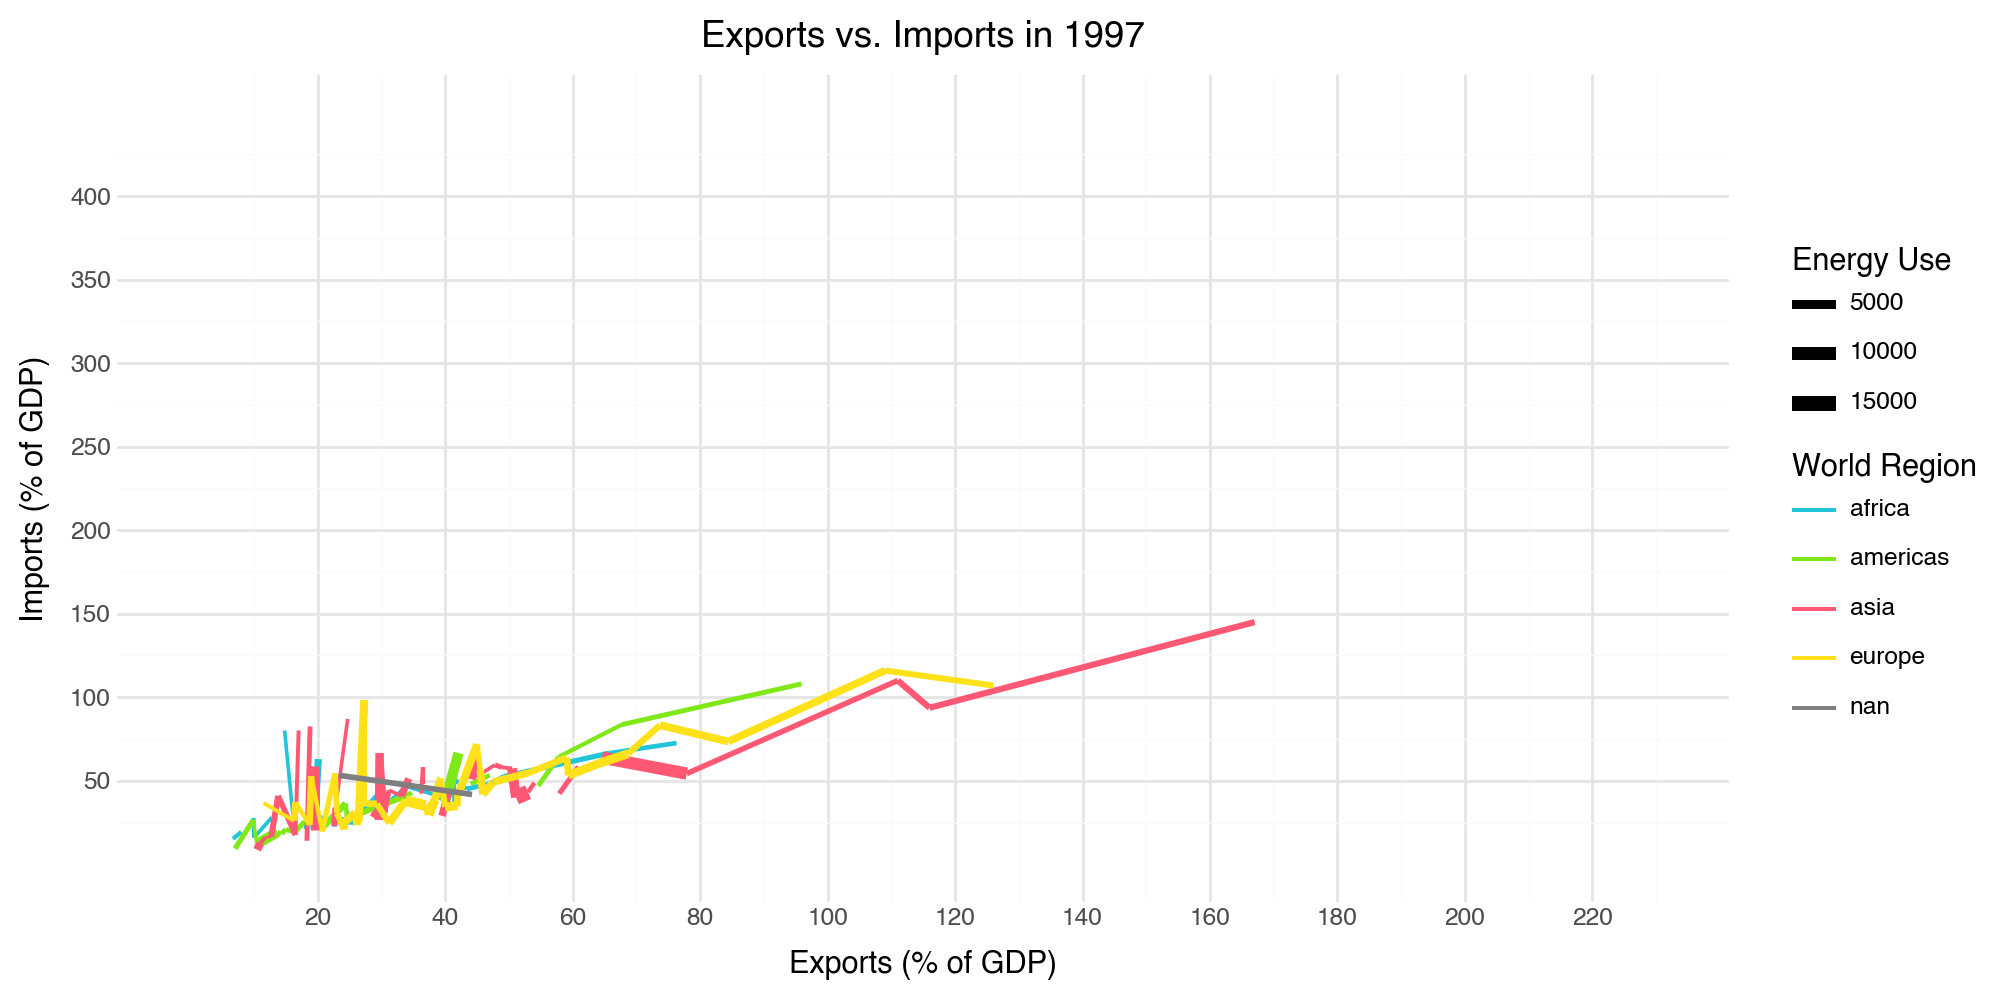

In [34]:
# geom line
(
    ggplot(q2_plot, aes(
        x='exports',
        y='imports',
        color='four_regions',
        size='energy'
    ))

    + geom_line()

    + scale_x_continuous(
        breaks=[20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220],
        limits=(0, 230)
    )

    + scale_y_continuous(
        breaks=[50, 100, 150, 200, 250, 300, 350, 400],
        limits=(0, 450)
    )

    + scale_size_continuous(
        range=(0.5, 3)
    )

    + scale_color_manual(values={
    'africa': '#21C4D8',
    'americas': '#7FE817',
    'asia': '#FF5874',
    'europe': '#FFE11A'
    })
    + labs(
        title="Exports vs. Imports in 1997",
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
        color="World Region",
        size="Energy Use"
    )

    + theme_minimal()
    + theme(
        figure_size=(10, 5)
    )
)

3a Is this plot good or bad for visualizing this data?

This geom_line(), works with all the given variables for this exercise because there are the exports and imports on the axes, the regions are represented by their colors, and the energy usage is depicted by the size.The relationship between the export and imports are easily visible.

One of the faults in this geometry is that the lines connect different countries, into their one same region. Even though it is technically depicted, the lines can make it precieved as the countries are related to each other when they aren't. The line thickness as well makes it harder to compare the energy use of each country, it is not as digestable as the other plots.


Overall, the line plot depicts all the given variables, but compared to the other geometry, there are better resulting plots with each country to its own.

# ----------------------------------------------

## **PLOT 3**

In [35]:
# import data set
import pandas as pd
from plotnine import *

In [36]:
q3_plot = pd.read_csv("https://raw.githubusercontent.com/mar7neh-ctrl/lab1-gapminder/refs/heads/main/Data/q3data.csv")

In [37]:
q3_plot

,internet_users,gdp,income,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,0.00456,330.0,1190.0,2001,Afghanistan,asia,south_asia,asia_west,South Asia
1,0.39000,2570.0,6780.0,2001,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,1.59000,3770.0,9230.0,2001,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,10500.0,NaN,2001,American Samoa,NaN,NaN,NaN,NaN
4,11.30000,42600.0,35600.0,2001,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia
...,...,...,...,...,...,...,...,...,...
210,1.85000,847.0,3270.0,2001,Vietnam,asia,east_asia_pacific,east_asia_pacific,East Asia & Pacific
211,27.50000,36700.0,NaN,2001,Virgin Islands (U.S.),NaN,NaN,NaN,NaN
212,0.51900,1190.0,4940.0,2001,Yemen,asia,middle_east_north_africa,asia_west,Middle East & North Africa
213,0.47800,991.0,2080.0,2001,Zambia,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


1. what aesthetics are being used, which variables are being mapped to each aesthetic

      point = country

      x = internet_users

      y = gdp

      color = four_regions

      size = income

2. recreate the plot using plotnine
must have: the geometry, the aesthetics, the scales

In [38]:
q3_plot.dtypes

internet_users       float64
gdp                  float64
income               float64
year                   int64
country               object
four_regions          object
six_regions           object
eight_regions         object
world_bank_region     object
dtype: object

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 12 rows containing missing values.


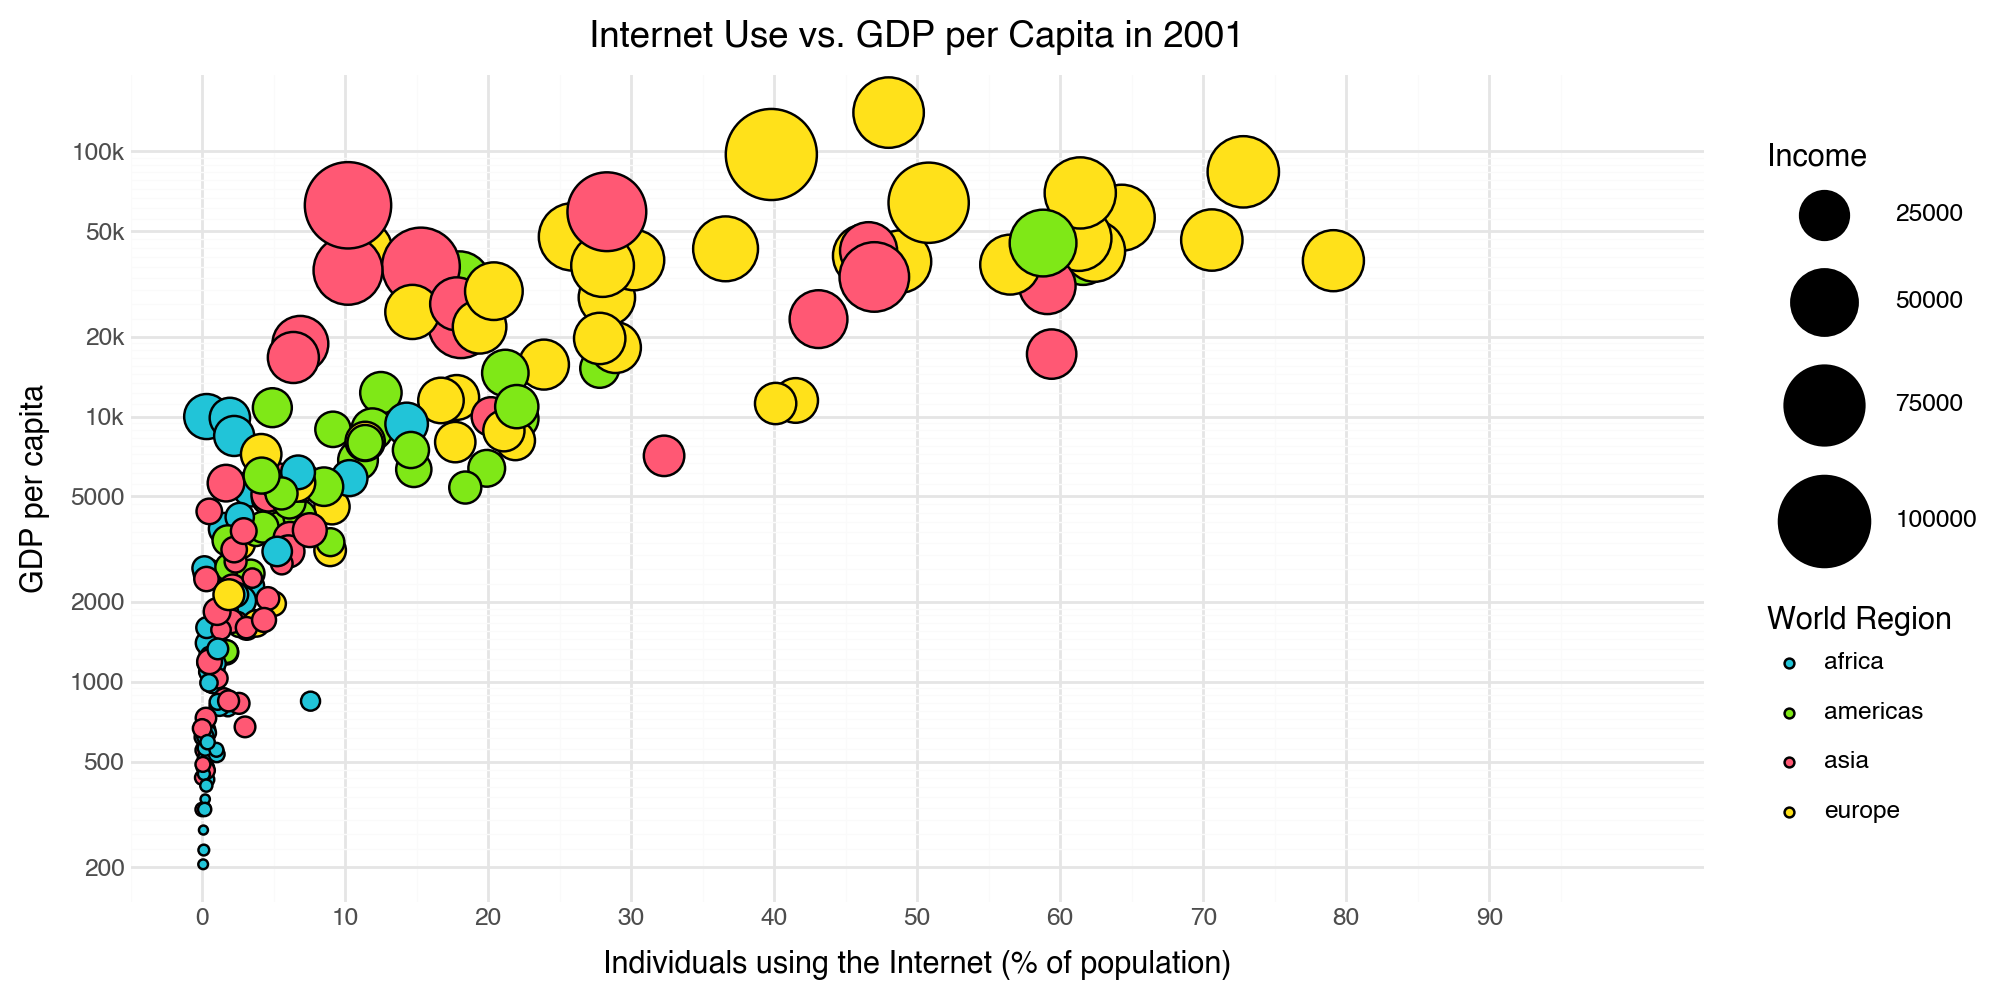

In [39]:
# dropping missing vals in region nan
q3_plot = q3_plot.dropna(subset=['four_regions'])

(
    ggplot(q3_plot, aes(
        x='internet_users',
        y='gdp',
        fill='four_regions',
        size='income'
    ))

    + geom_point(
        shape='o',
        color='black',
        stroke=0.5
    )

    + scale_x_continuous(
        breaks=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
        limits=(0, 100)
    )

    + scale_y_log10(
        breaks=[200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000],
        labels=['200', '500', '1000', '2000', '5000', '10k', '20k', '50k', '100k']
    )

    + scale_size_continuous(
        range=(1,18)
    )

    + scale_fill_manual(values={
        'africa': '#21C4D8',
        'americas': '#7FE817',
        'asia': '#FF5874',
        'europe': '#FFE11A'
    })

    + labs(
        title="Internet Use vs. GDP per Capita in 2001",
        x="Individuals using the Internet (% of population)",
        y="GDP per capita",
        fill="World Region",
        size="Income"
    )

    + theme_minimal()
    + theme(
        figure_size=(10, 5)
    )
)

3. what other geometries could you use here besides geom_point?

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_jitter : Removed 12 rows containing missing values.


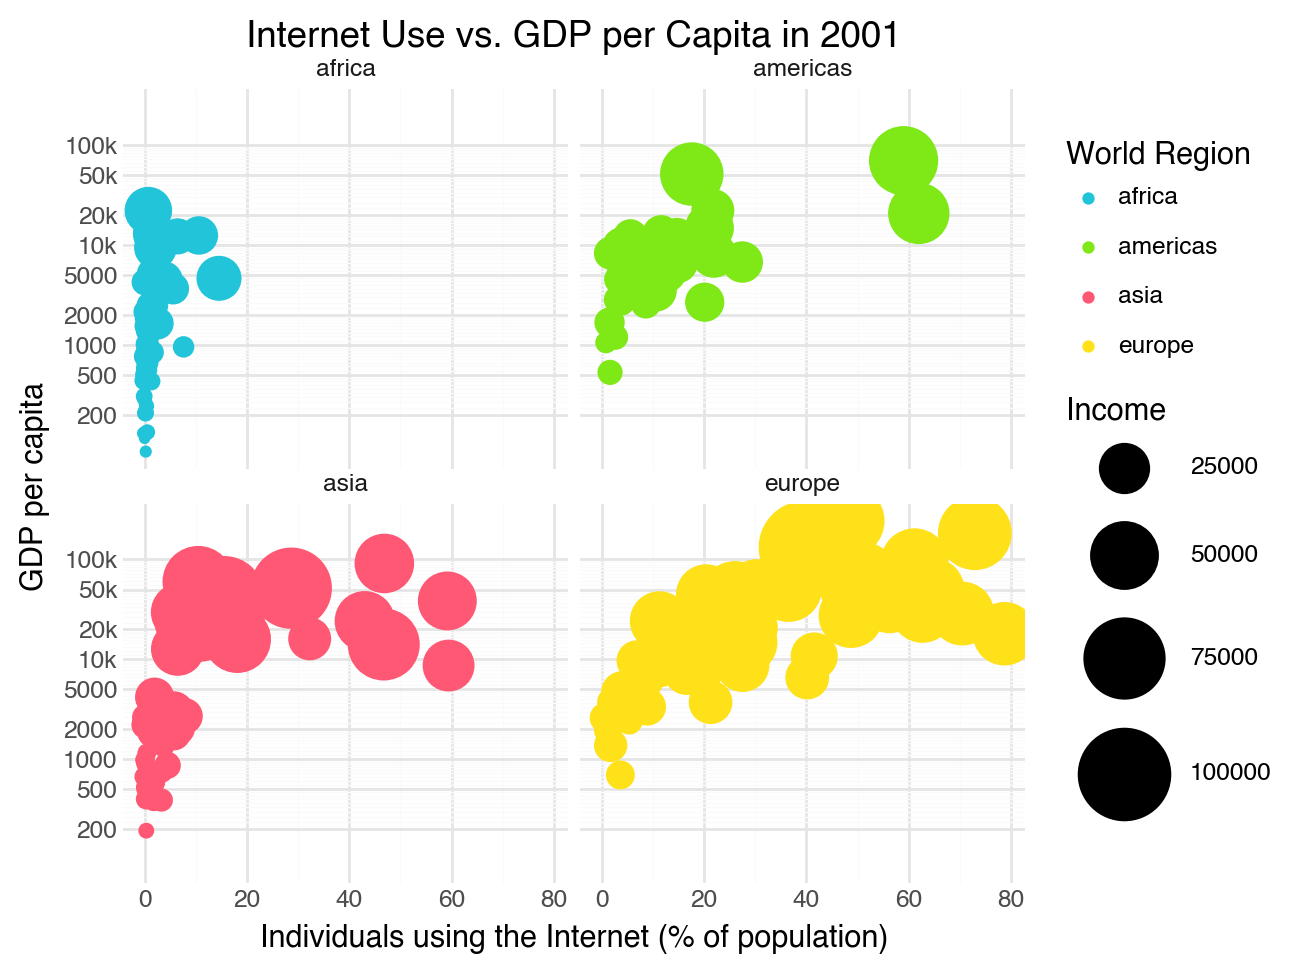

In [40]:
# geom jitter + facet wrap
(
    ggplot(q3_plot, aes(
        x='internet_users',
        y='gdp',
        size='income',
        color='four_regions'
    ))

    + geom_jitter()

    + facet_wrap('four_regions')

    + scale_y_log10(
        breaks=[200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000],
        labels=['200', '500', '1000', '2000', '5000', '10k', '20k', '50k', '100k']
    )

    + scale_color_manual(values={
        'africa': '#21C4D8',
        'americas': '#7FE817',
        'asia': '#FF5874',
        'europe': '#FFE11A'
    })

    + scale_size_continuous(
        range=(1, 18)
    )

    + labs(
        title="Internet Use vs. GDP per Capita in 2001",
        x="Individuals using the Internet (% of population)",
        y="GDP per capita",
        color="World Region",
        size="Income"
    )

    + theme_minimal()

)

3a Is this plot good or bad for visualizing this data?

This plot of not only jitter but facet wrapping is useful because it allows us to take a look at the relationships between internet usage and GDP per capita in a less overwhelming way. All four of the plots are analyzing the same things, but within each of the 4 world regions. The fact wrapping makes it easier to see those progressions of the countries with larger internet usage that also have higher GDP per capita. The size depicted helps show the information about the income of those invidiuals as well which is good for making additional assumptions. Using geom_jitter(), was very helpful for spacing out the country points that can overlap and become overwhleming to look at so this way there is better visibility.

One disadvantage with using this plot is that spacing out the regions into different plots makes the comparisons of specific circles/countries a bit more of a hassle. This is because before if they overlapped, one could see the physical overlap of the circles and now this way, we must check using some ruler or method of thumb. Also, since jitter does make changes in how the observations are spaced out, these plot results are much more applicable to just taking a look at the different progressions/patterns than searching for exact values.

Overall, I think this is much easier for analyzing between the different regions and their fewer overlap but there are again much better ways to go about these variables.

